In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.metrics import r2_score, mean_squared_error

### Task: Connect to "Python training characteristics" table in GCP and load it into this python environment

In [4]:
df = pd.read_csv("eqfx_customers_data.csv").drop('Unnamed: 0', axis=1)
df

<ipython-input-4-aa83ab32f0d7>:1: DtypeWarning: Columns (10,11,13,15,17,18,22,23,24,25,30,34,35,39,40,42,43,50,51,54,60,63,67,69,76,78,80,82,83,86,89,101,102,103,108,109,112,113,118,119,122,125,129,130,133,134,136,137,139,179,197,198,205,209,221,239,240,241,242) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("eqfx_customers_data.csv").drop('Unnamed: 0', axis=1)


,outref10,efx_gbflag,efx_weight,RNISF05,RNILF05,EIILF52,EIILF51,ZSC009,ZSC060,ZSQ009,...,SSQ16,CSC3,CSC40,CSC41,CSC51,LSQ072,LSC250,LSC350,LSC599,LSC251
0,1000280528,1,1.727625,450,435,191,215,4.99,-1.04,4.99,...,M,M,M,M,M,C,15,23,1650,99
1,1000576212,0,1.000000,431,431,196,234,-0.84,-0.03,-0.84,...,M,M,M,M,M,C,11,15,36900,99
2,1000793119,1,1.727625,454,439,188,234,6.42,0.38,6.42,...,M,M,M,M,M,C,17,26,4950,99
3,1000014856,0,6.252772,369,395,233,281,3.29,-1.35,3.29,...,1,M,M,M,M,C,14,21,6850,99
4,1000103116,0,1.000000,505,537,183,197,-0.5,1.15,-0.5,...,C,M,M,M,M,C,19,36,18550,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74713,1000566661,0,1.727625,352,352,190,212,M,M,C,...,7,M,M,M,M,C,M,M,M,M
74714,1000700641,0,1.727625,429,429,176,213,M,M,0,...,M,M,M,M,M,C,M,M,M,M
74715,1000702441,0,1.000000,516,516,140,181,M,M,-2.23,...,C,M,M,M,M,C,M,M,M,M
74716,1000704770,0,1.000000,482,482,168,222,M,M,3.85,...,C,M,M,M,M,C,M,M,M,M


In [5]:
desc_df = pd.read_csv("cleaner_headers.csv")
desc_df

,Unnamed: 0,Code,Description
0,0,RNISF05,All Markets RN 5 Full RN Opt in subject and as...
1,1,RNILF05,All Markets RN 5 Full RN Opt in subject and as...
2,2,CSC3,CCJ-First Applicant-Current Address: Number of...
3,3,CSC40,CCJ-First Applicant-Current Address: Number of...
4,4,CSC51,CCJ-First Applicant-Current Address: Number of...
...,...,...,...
238,238,FSC359,Indebtedness-First Applicant-Current Address: ...
239,239,FSC128,Indebtedness-First Applicant-Current Address: ...
240,240,FSC127,Indebtedness-First Applicant-Current Address: ...
241,241,FSC394,Indebtedness-First Applicant-Current Address: ...


# Improving Data Quality and Predictive modelling:
## **Equifax Customer credit account data**

# Predictive modelling for KPI
The KPI or core metric we are interested in predicting is 'exp_flag'  [Equifax Performance Flag (1 = Bad, 0 = Good)]. This is a binary class outcome and best suited for classification modelling. The type of modelling will depend on the kind of data we can use.

**Objectives**

*   Obj1: Which classification methods can handle Nulls?
*   Obj2: Identify the fields that are most applicable to building a predictive model to classify the KPI
*   Obj3: What data quality issues do these fields present?

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74718 entries, 0 to 74717
Columns: 242 entries, outref10 to LSC251
dtypes: float64(1), int64(6), object(235)
memory usage: 138.0+ MB


In [7]:
#print(df["efx_gbflag"].value_counts())
df["efx_gbflag"].value_counts()

,count
efx_gbflag,
0,71702
1,3016


In [28]:
df_clean = df.apply(pd.to_numeric, errors='coerce')

In [29]:
# counting number of values present in column,
# filtering to only see columns with over 25000 entries
count_table = df_clean.count()
keep_cols_table = count_table[count_table > 25000]
keep_cols_table.sort_values(ascending=False)

#This results in 100 columns being filtered out for insufficient completeness

,0
outref10,74718
efx_gbflag,74718
efx_weight,74718
RNISF05,74718
RNILF05,74718
...,...
ZAC009,28245
ZAC006,28245
ZAC004,26860
LSQ566,26672


In [30]:
df.isna().any().sum()

np.int64(0)

### Task : Create a dataframe without columns that have less than 50% complete entries

In [31]:
df_clean = df_clean[keep_cols_table.index]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74718 entries, 0 to 74717
Columns: 181 entries, outref10 to LSC251
dtypes: float64(175), int64(6)
memory usage: 103.2 MB


## Data preparation for Classification modelling

✅ Algorithms That Can Handle Nulls Natively or Gracefully
1. Decision Trees and Ensemble Methods (some implementations)
XGBoost:

✅ Natively handles missing values.

It learns optimal default directions when missing values are encountered.

xgboost.XGBClassifier in Python handles NaNs automatically.

Ref: Chen & Guestrin, 2016 – XGBoost: A Scalable Tree Boosting System

LightGBM:

✅ Handles NaNs internally during split finding.

Treats missing values as a separate split candidate.

Ref: Ke et al., 2017 – LightGBM: A Highly Efficient Gradient Boosting Decision Tree

CatBoost:

✅ Handles categorical and missing values without preprocessing.

Uses a data-driven approach for imputing during training.

Ref: Prokhorenkova et al., 2018 – CatBoost: Unbiased Boosting with Categorical Features

❌ Algorithms That Do Not Tolerate Nulls
Most of these will fail with NaNs unless you impute beforehand:

Logistic Regression

SVMs

k-Nearest Neighbours (KNN)

Naive Bayes

**Task:** what is the percentage of null values for each column in a dataframe, save those counts in a dataframe.

Some Classification approaches accept Nulls, most do not.






## Is there a significant relationship between the KPI and other input fields?

In [16]:
df_clean.corr()['efx_gbflag'].sort_values(ascending=False)

,efx_gbflag
efx_gbflag,1.000000
TSQ438,0.117615
LSQ565,0.113285
LSC565,0.113276
TSC137,0.110582
...,...
LSC203,NaN
LSC204,NaN
LSC202,NaN
CSC51,NaN


Assessment:
Nothing that seemingly strongly correlates, however the KPI is binary so correlation isnt as strong an indicator

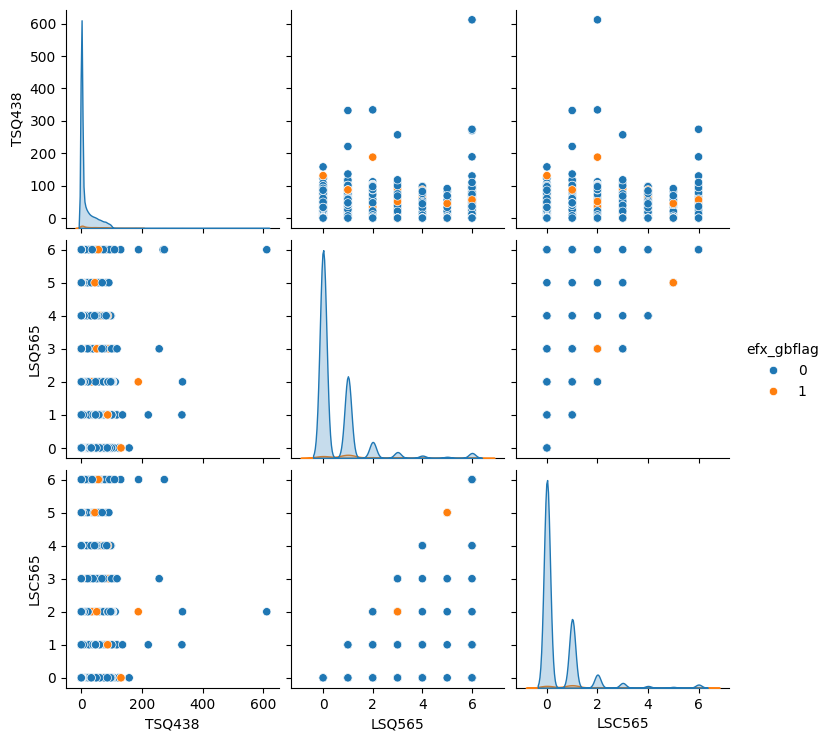

In [17]:
sns.pairplot(df_clean[["TSQ438", "LSQ565", "LSC565", "efx_gbflag"]], hue="efx_gbflag")

Balance the sample sizes with SMOTE
- Handle potential missing values in the features before applying SMOTE
- SMOTE does not inherently handle missing values, so we need to impute them.
- A simple strategy is mean imputation, but you might want to explore more sophisticated methods.

In [18]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_clean.drop('efx_gbflag', axis=1)
y = df_clean['efx_gbflag']

# Split data into training and testing sets before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Note: SMOTE is applied only to the training data to prevent data leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original dataset shape %s" % y_train.value_counts())
print("Resampled dataset shape %s" % y_train_resampled.value_counts())

Original dataset shape efx_gbflag
0    57361
1     2413
Name: count, dtype: int64
Resampled dataset shape efx_gbflag
0    57361
1    57361
Name: count, dtype: int64


In [32]:
X_train.isna().sum()

,0
outref10,0
efx_weight,0
RNISF05,0
RNILF05,0
EIILF52,0
...,...
LSQ072,0
LSC250,0
LSC350,0
LSC599,0


In [33]:
'''from sklearn.impute import SimpleImputer

#impute missing values in dataset with mean (BETTER WITH MODELLING THOUGH)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)


# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed_df, y)

# Check the new class distribution
print("Distribution before SMOTE:")
print(y.value_counts())
print("\nDistribution after SMOTE:")
print(y_resampled.value_counts())

# X_resampled and y_resampled now contain the balanced dataset
''';

In [34]:
#build a classification model using the smoted data and evaluate

In [35]:
# prompt: build a classification model using the smoted data and evaluate

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize a classification model (e.g., Logistic Regression)
model = LogisticRegression(random_state=42, solver='liblinear') # using liblinear solver for smaller datasets

# Train the model on the SMOTE-resampled training data
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.71      0.83     14341
           1       0.10      0.74      0.17       603

    accuracy                           0.71     14944
   macro avg       0.54      0.72      0.50     14944
weighted avg       0.95      0.71      0.80     14944


Confusion Matrix:
[[10180  4161]
 [  157   446]]

ROC AUC Score:
0.7951581608032634



Decision Tree Evaluation:
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     14341
           1       0.10      0.28      0.15       603

    accuracy                           0.87     14944
   macro avg       0.53      0.58      0.54     14944
weighted avg       0.93      0.87      0.90     14944


Confusion Matrix:
[[12825  1516]
 [  437   166]]

ROC AUC Score:
0.7092967050020565


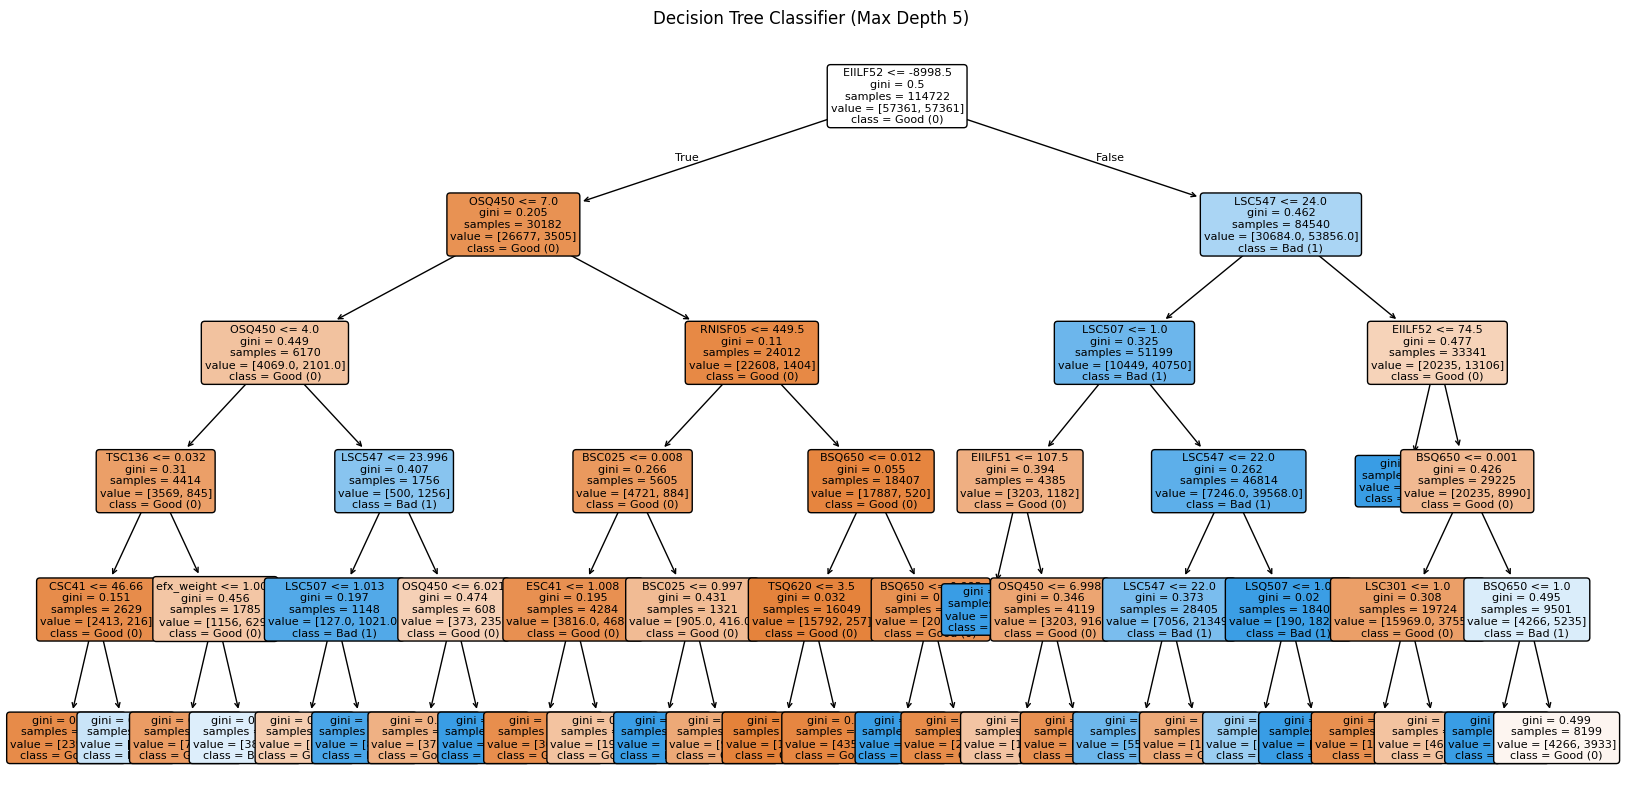

In [36]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Build the Decision Tree model
# Using max_depth to prevent overfitting and min_samples_leaf to ensure sufficient samples
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=20)

# Train the model on the SMOTE-resampled training data
dt_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test data
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate the Decision Tree model
print("\nDecision Tree Evaluation:")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba_dt))

# Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_train_resampled.columns, class_names=['Good (0)', 'Bad (1)'], filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Classifier (Max Depth 5)")
plt.show()


Random Forest Evaluation:
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.84      0.90     14341
         1.0       0.12      0.50      0.19       603

    accuracy                           0.83     14944
   macro avg       0.55      0.67      0.54     14944
weighted avg       0.94      0.83      0.87     14944


Confusion Matrix:
[[12042  2299]
 [  303   300]]

ROC AUC Score:
0.7689177129946576

Top 10 Features by Importance:
     feature  importance
4    EIILF52    0.093221
24    OSQ451    0.058335
31    OSQ450    0.058265
5    EIILF51    0.051999
109   BSQ650    0.046026
42    OSC451    0.030520
28    TSQ438    0.030031
161   TSQ601    0.029724
2    RNISF05    0.029670
68    LSC547    0.029192


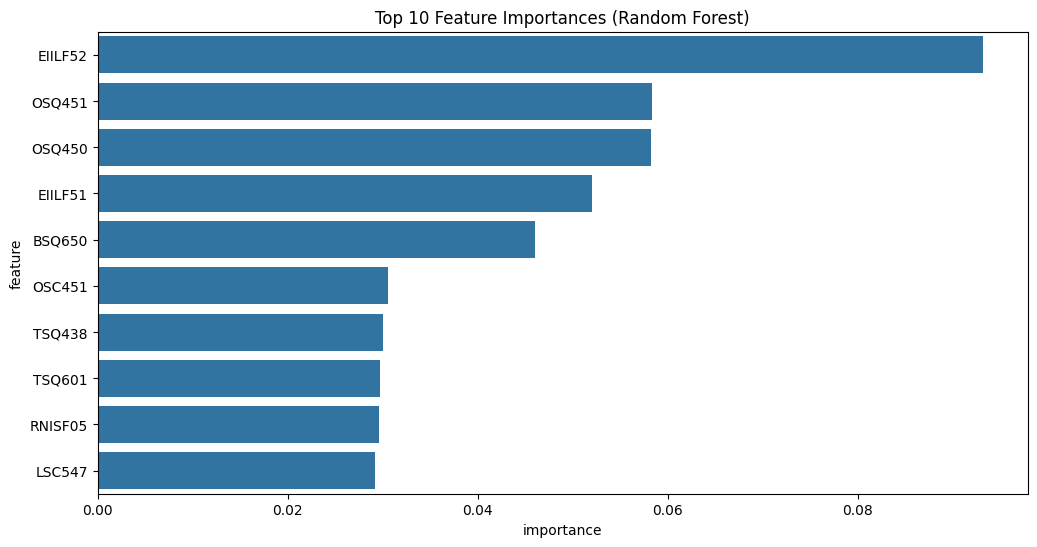

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialise the Random Forest model
# Using a reasonable number of estimators and max_depth
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, min_samples_leaf=20, n_jobs=-1)

# Train the model on the SMOTE-resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test data
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the Random Forest model
print("\nRandom Forest Evaluation:")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba_rf))

# Optional: Feature Importance
importances = rf_model.feature_importances_
feature_names = X_train_resampled.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("\nTop 10 Features by Importance:")
print(feature_importance_df.head(10))

# Plotting feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()


In [ ]:
import pickle

# Save the trained Random Forest model
filename = 'random_forest_model.pkl'
pickle.dump(rf_model, open(filename, 'wb'))

# Download the model file
from google.colab import files
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## ALTERNATIVELY for keeping it in the GCP ecosystem
1. Uploading Dataframe to GCP
2. Uploading Model to GCP

## UPLOAD DF TO GCP
2 Options
1. Big Query client, load table form dataframe
2. Big Frames package's to_gbq() streamlines process.

In [ ]:
#### OPTION 1 -- UPLOAD DF TO GCP ####

from google.cloud import bigquery

# Init BigQuery client
client = bigquery.Client()

# Define destination table
table_id = "your-project.your_dataset.your_table"

# Upload DataFrame
job = client.load_table_from_dataframe(df, table_id)
job.result()  # Wait for completion

print(f"Uploaded {job.output_rows} rows to {table_id}")

In [ ]:
#### OPTION 2 -- UPLOAD DF to GCP ####

import bigframes.pandas as bpd

bdf = bpd.from_pandas(df)
bdf.to_gbq("your-project.your_dataset.your_table", if_exists="replace")

## UPLOAD MODEL TO GCP
Two options

1.   Upload the trained model (.pkl, joblib) to Google Cloud Storage
2.   Register model with Vertex AI

In [ ]:
#UPLOAD TRAINED MODEL like .pkl and .joblib to GC Storage

from google.cloud import storage
import joblib

# Save model locally
joblib.dump(model, "model.pkl")

# Upload to GCS
client = storage.Client()
bucket = client.bucket("your-gcs-bucket")
blob = bucket.blob("models/model.pkl")
blob.upload_from_filename("model.pkl")

print("Model uploaded to GCS.")


In [ ]:
# REGISTER MODEL with VERTEX AI

from google.cloud import aiplatform

aiplatform.init(project="your-project", location="europe-west4")

model = aiplatform.Model.upload(
    display_name="my-model",
    artifact_uri="gs://your-gcs-bucket/models/",
    serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.0-24:latest"
)
